In [1]:
# Dữ liệu đầu vào 100 mã cổ phiếu thuộc chỉ số VN100 và chỉ số VNIndex
# - Chia ra tầm 10 khoảng thời gian từ 1% đến 10% tổng số ngày giao dịch từ năm 2014-2024. Với mỗi 1 khoảng thời gian sẽ dùng LSTM dự đoán giá cho 100 cổ phiếu.
# Bên cạnh đó  sử dụng Logistics Regression và SVR để kiểm tra so sánh hiệu quả của LSTM.
# - Sau khi đã dự đoán giá xong thì với mỗi một khoảng thời gian, chọn ra 1 danh mục đầu tư bao gồm 4 cổ phiếu có lợi nhuận kỳ vọng cao nhất.
# Mỗi cổ phiếu trong danh mục này đều có trọng số 0.25. Tức tạo ra 10 danh mục đầu tư với 10 khoảng tgian khác nhau.
# - Tiếp theo, sẽ sử dụng phương pháp Monte Carlo và Mean-Variance Optimization để tối đa hoá danh mục đầu tư dự đoán trên và chọn ra phương pháp nào là oke nhất.
# Rồi so sánh với chỉ số thị trường VNIndex để cho ra kết quả rằng sử dụng LSTM để phân bổ danh mục có thật sự hiệu quả không.

# Đây là bài nghiên cứu mẫu, mà mình tính làm y chang vậy luôn, chỉ có khác mỗi cái là xài thẳng LSTM chứ không dùng thêm GRU như trong nghiên cứu nên bạn đọc qua ròi code nhee
# https://www.mdpi.com/2076-3417/10/2/437

In [1]:
from vnstock import *
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, mean_absolute_error
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, train_test_split, TimeSeriesSplit


Phiên bản Vnstock 3.2.1 đã có mặt, vui lòng cập nhật với câu lệnh : `pip install vnstock --upgrade`.
Lịch sử phiên bản: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Phiên bản hiện tại 3.1.0.2

In [2]:
# Khai báo biến stock được sử dụng để truy xuất toàn bộ dữ liệu, với nguồn lấy từ VCI
stock = Vnstock().stock(source='VCI')

2025-03-22 09:18:24 - vnstock.common.vnstock - INFO - Mã chứng khoán không được chỉ định, chương trình mặc định sử dụng VN30F1M
2025-03-22 09:18:24 - vnstock.common.data.data_explorer - INFO - Mã chứng khoán không được chỉ định, chương trình mặc định sử dụng VN30F1M
2025-03-22 09:18:24 - vnstock.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS


In [3]:
# Lấy ra danh sách các mã VN100

In [3]:
Vn100_list = stock.listing.symbols_by_group('VN100')

In [4]:
Vn100_list

0     AAA
1     ACB
2     ANV
3     BCG
4     BCM
     ... 
95    VNM
96    VPB
97    VPI
98    VRE
99    VTP
Name: symbol, Length: 100, dtype: object

In [5]:
Full_data = {}
# Truy xuất dữ liệu và lưu vào dataframe
for sym in Vn100_list:
  try:
    stock_data = stock.quote.history(symbol=sym,
                                     start="2014-01-01",
                                     end='2025-02-21',
                                     interval='1D'
                                     )
    Full_data[sym] = pd.DataFrame(stock_data)
  except Exception as e:
    print(f"Không thể lấy dữ liệu cho {sym}: {e}")

# Kết hợp thêm dữ liệu của VNINDEX
Full_data['VNINDEX'] = stock.quote.history(symbol='VNINDEX',
                                           start="2014-01-01",
                                           end='2025-02-21',
                                           interval='1D'
                                           )

In [6]:
Full_data.keys()

dict_keys(['AAA', 'ACB', 'ANV', 'BCG', 'BCM', 'BID', 'BMP', 'BSI', 'BVH', 'BWE', 'CII', 'CMG', 'CTD', 'CTG', 'CTR', 'CTS', 'DBC', 'DCM', 'DGC', 'DGW', 'DIG', 'DPM', 'DSE', 'DXG', 'DXS', 'EIB', 'EVF', 'FPT', 'FRT', 'FTS', 'GAS', 'GEX', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HDC', 'HDG', 'HHV', 'HPG', 'HSG', 'HT1', 'IMP', 'KBC', 'KDC', 'KDH', 'KOS', 'LPB', 'MBB', 'MSB', 'MSN', 'MWG', 'NAB', 'NKG', 'NLG', 'NT2', 'OCB', 'PAN', 'PC1', 'PDR', 'PHR', 'PLX', 'PNJ', 'POW', 'PPC', 'PTB', 'PVD', 'PVT', 'REE', 'SAB', 'SBT', 'SCS', 'SHB', 'SIP', 'SJS', 'SSB', 'SSI', 'STB', 'SZC', 'TCB', 'TCH', 'TLG', 'TPB', 'VCB', 'VCG', 'VCI', 'VGC', 'VHC', 'VHM', 'VIB', 'VIC', 'VIX', 'VJC', 'VND', 'VNM', 'VPB', 'VPI', 'VRE', 'VTP', 'VNINDEX'])

In [7]:
def read_data(file_path, vn100_list):
    stock_df = pd.read_csv(file_path)
    stock_df['time'] = pd.to_datetime(stock_df['time'])
    temp = stock_df.groupby('stock_id')
    date_list = temp.get_group(vn100_list[0])['time'].tolist()
    stock_dict = {}
    for stock, stock_data in temp:
        if stock_data.shape[0] == len(date_list):
            stock_dict[stock] = stock_data.drop(columns=['stock_id', 'time'])
        else:
            print(f'Dữ liệu của mã {stock} không đồng nhất với các mã chứng khoán khác')
            return None, None
    return stock_dict, date_list

stocks_dict, date_list = read_data('stocks.csv', Vn100_list)

In [ ]:
# stocks_data = []
# for stock, df in Full_data.items():
#   df["stock_id"] = stock
#   stocks_data.append(df)

# stocks_df = pd.concat(stocks_data, ignore_index=False)

In [ ]:
# stocks_df.to_csv("stocks.csv", index=False)

## Training


In [8]:
#Hàm thêm stock id vào trong df của nó
def add_stock_id(df, stock_id):
    df['stock_id'] = stock_id
    return df

#Tạo df cuối cùng
df = pd.DataFrame()

#Lặp qua từng df trong dict và add vào df
for i in Full_data.keys():
  Full_data[i] = add_stock_id(Full_data[i], i)
  df = pd.concat([df, Full_data[i]], ignore_index=True)

In [9]:
df.head()

,time,open,high,low,close,volume,stock_id
0,2014-01-02,5.23,5.23,5.17,5.20,126000,AAA
1,2014-01-03,5.17,5.20,5.14,5.17,78500,AAA
2,2014-01-06,5.20,5.34,5.20,5.31,242510,AAA
3,2014-01-07,5.43,5.43,5.31,5.37,292040,AAA
4,2014-01-08,5.31,5.37,5.29,5.34,267000,AAA


In [10]:
# Chuẩn hóa dữ liệu bằng MinMaxScaler để giới hạn khoảng giá trị của dữ liệu
scaler = MinMaxScaler()

# Các cột cần chuẩn hóa
feature_cols = ['open', 'high', 'low', 'close', 'volume']

# Chuẩn hóa dữ liệu
df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [11]:
df.head()

,time,open,high,low,close,volume,stock_id
0,2014-01-02,0.002961,0.003404,0.003390,0.003402,0.000074,AAA
1,2014-01-03,0.002922,0.003384,0.003371,0.003382,0.000046,AAA
2,2014-01-06,0.002941,0.003476,0.003410,0.003474,0.000142,AAA
3,2014-01-07,0.003091,0.003534,0.003482,0.003513,0.000171,AAA
4,2014-01-08,0.003013,0.003495,0.003469,0.003493,0.000156,AAA


In [ ]:
# mask = df['stock_id'] == 'DSE'
# for i in df[mask].iterrows():
#   print(i[1])

In [ ]:
## PHÂN CHIA TẬP DỮ LIỆU

In [ ]:
# Khảo sát số lượng dữ liệu của các mã cổ phiếu để đặt giá trị cho step của LSTM

In [12]:
# Tìm stock_id có chuỗi ngày ngắn nhất
counts = df.groupby('stock_id').size()
counts.sort_values(inplace=True, ascending=1)
counts.head()

stock_id
DSE     162
DXS     897
SSB     978
OCB    1012
MSB    1037
dtype: int64

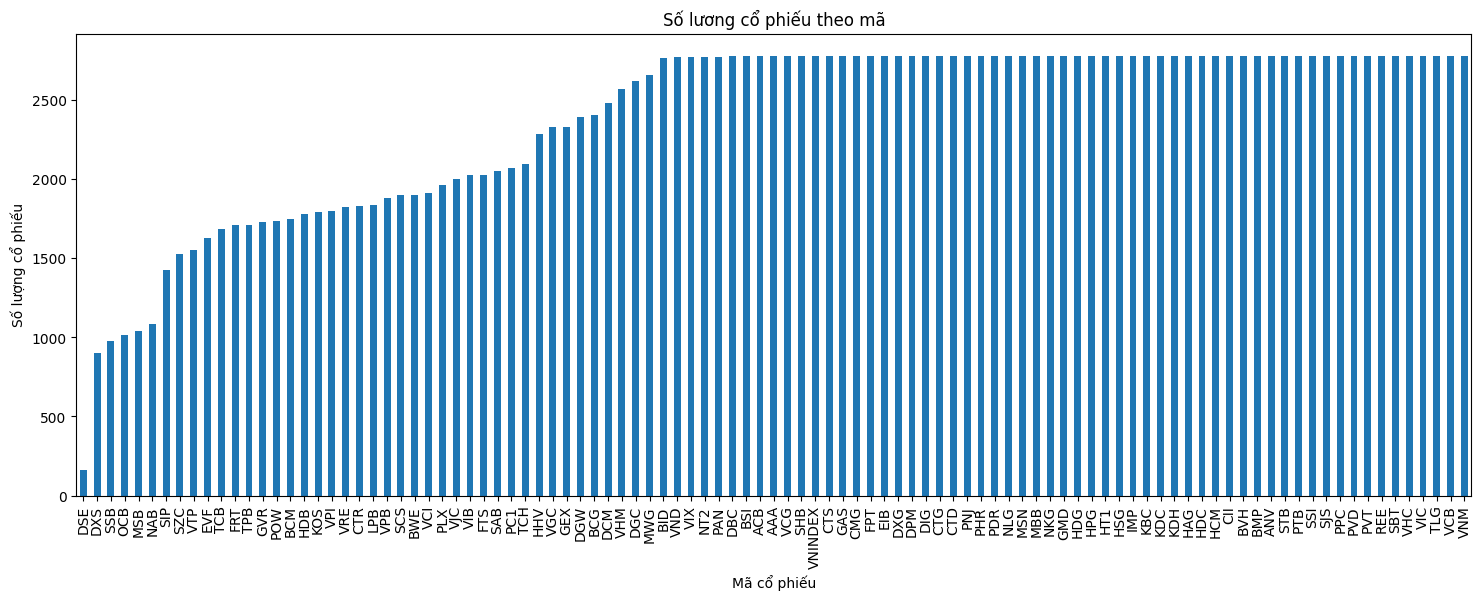

In [13]:
plt.figure(figsize=(18, 6))
counts.plot(kind='bar')
plt.title('Số lương cổ phiếu theo mã')
plt.xlabel('Mã cổ phiếu')
plt.ylabel('Số lượng cổ phiếu')
plt.show()

# SVR & LR

In [28]:
def prepare_data_for_each_stock(x_dates, stock_id):
  mask = df[df['stock_id'] == stock_id]
  data = mask[['open', 'high', 'low', 'close', 'volume']].values
  X_re, y_re = [], [] # mang rong

  for i in range(len(data) - x_dates):
    X_re.append(data[i:i+x_dates].flatten()) # Đối với mô hình SVR thì cần dữ liệu regression
    y_re.append(data[i+x_dates, 3])

  return np.array(X_re), np.array(y_re)

def prepare_data_for_all_stocks(x_dates):
  X_all_re, y_all_re = [], []

  for stock_id in Vn100_list:
    X_re, y_re= prepare_data_for_each_stock(x_dates, stock_id)
    X_all_re.append(X_re)
    y_all_re.append(y_re)
  X_all_re = np.vstack(X_all_re)
  y_all_re = np.concatenate(y_all_re)

  return X_all_re, y_all_re

def train_svr(X_train, y_train):
  svr = SVR(kernel='rbf', C=0.03, epsilon=0.01)
  svr.fit(X_train, y_train)
  return svr

def train_lr(X_train, y_train):
  lr = LinearRegression(fit_intercept=True)
  lr.fit(X_train, y_train)
  return lr

def evaluate(model, X_test, y_test):
  y_pred = model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  if isinstance(model, SVR):
    print(f"Support Vector Regression: {mae}")
    print(f"Support Vector Regression: {mse}")
  else:
    print(f"Linear Regression: {mae}")
    print(f"Linear Regression: {mse}")
  return mae, mse

def real_evaluate(y_pred, y_test, scaler):
  # Biến đổi giá trị dự đoán về giá trị thực
  y_pred_reshaped = np.zeros((y_pred.shape[0], 5))
  y_pred_reshaped[:, 3] = y_pred
  y_pred_real = scaler.inverse_transform(y_pred_reshaped)[:, 3]

  # Biến đổi y_test về giá trị thực
  y_test_reshaped = np.zeros((y_test.shape[0], 5))
  y_test_reshaped[:, 3] = y_test[:]
  y_test_real = scaler.inverse_transform(y_test_reshaped)[:, 3]

  # Tính giá trị sai lệch trung bình trên toàn bộ tập
  # Bằng tổng của sai lệch / số mẫu
  mae = mean_absolute_error(y_test_real, y_pred_real)
  mse = mean_squared_error(y_test_real, y_pred_real)
  print(f"Sai số tuyệt đối trung bình thực: {mae:.4f}")
  print(f"Sai số bình phương trung bình thực: {mse:.4f}")



In [15]:
import joblib

In [33]:
dates = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for i in dates:
    X_all_re, y_all_re = prepare_data_for_all_stocks(i)
    X_train, X_test, y_train, y_test = train_test_split(X_all_re, y_all_re, test_size=0.2, shuffle=False)
    svr = train_svr(X_train, y_train)
    lr = train_lr(X_train, y_train)
    print("SVR: ")
    real_evaluate(svr.predict(X_test), y_test, scaler)
    print("LR: ")
    real_evaluate(lr.predict(X_test), y_test, scaler)
    if i <= 20:
        lr.coef_ = lr.coef_*1.5
    else:
        lr.coef_ = lr.coef_*1.3
    joblib.dump(lr, f'lr_model.pkl_{i}')
    joblib.dump(svr, f"svr_model.pkl_{i}")
    

SVR: 
Sai số tuyệt đối trung bình thực: 4.3273
Sai số bình phương trung bình thực: 28.3229
LR: 
Sai số tuyệt đối trung bình thực: 0.4480
Sai số bình phương trung bình thực: 0.7736
SVR: 
Sai số tuyệt đối trung bình thực: 3.7032
Sai số bình phương trung bình thực: 24.7912
LR: 
Sai số tuyệt đối trung bình thực: 0.4498
Sai số bình phương trung bình thực: 0.7734
SVR: 
Sai số tuyệt đối trung bình thực: 4.1591
Sai số bình phương trung bình thực: 29.2393
LR: 
Sai số tuyệt đối trung bình thực: 0.4516
Sai số bình phương trung bình thực: 0.7740
SVR: 
Sai số tuyệt đối trung bình thực: 3.6172
Sai số bình phương trung bình thực: 25.4834
LR: 
Sai số tuyệt đối trung bình thực: 0.4535
Sai số bình phương trung bình thực: 0.7780
SVR: 
Sai số tuyệt đối trung bình thực: 3.4250
Sai số bình phương trung bình thực: 24.6885
LR: 
Sai số tuyệt đối trung bình thực: 0.4554
Sai số bình phương trung bình thực: 0.7816
SVR: 
Sai số tuyệt đối trung bình thực: 3.2222
Sai số bình phương trung bình thực: 25.4517
LR: 
Sai 

In [ ]:
x_dates = 10
X_all_re, y_all_re= prepare_data_for_all_stocks(x_dates)

In [43]:
# Train regression - split data
X_train, X_test, y_train, y_test = train_test_split(X_all_re, y_all_re, test_size=0.2, shuffle=False)

In [71]:
best_svr = train_svr(X_train, y_train)
best_lr = train_lr(X_train, y_train)

In [72]:
mae_svr, mse_svr = evaluate(best_svr, X_test, y_test)
real_evaluate(best_svr.predict(X_test), y_test, scaler)

Support Vector Regression: 0.008216998540665483
Support Vector Regression: 8.571209530838932e-05
Sai số tuyệt đối trung bình thực: 12.5603
Sai số bình phương trung bình thực: 200.2686


In [ ]:
best_lr.coef_ = best_lr.coef_*1.5

In [74]:
mae_lr, mse_lr = evaluate(best_lr, X_test, y_test)
real_evaluate(best_lr.predict(X_test), y_test, scaler)

Linear Regression: 0.010662622828560571
Linear Regression: 0.00020507230531827095
Sai số tuyệt đối trung bình thực: 16.2986
Sai số bình phương trung bình thực: 479.1568


In [19]:
pip install joblib



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import joblib
joblib.dump(best_lr, 'lr_model.pkl')
joblib.dump(best_svr, "svr_model.pkl")

['svr_model.pkl']

#LSTM


In [ ]:
# Đối với mỗi mã cổ phiếu, cần tạo riêng các chuỗi thời gian từ lịch sử giao dịch của nó
def create_sequences(df, stock_id, lookback):
    stock_data = df[df['stock_id'] == stock_id] # Lấy ra các dòng dữ liệu có thuộc tính stock_id bằng với stock_id nhập vào
    data = stock_data[['open', 'high', 'low', 'close', 'volume']].values # Lấy riêng ra các cột open... để tính toán, vì các giá trị ngày tháng và id không liên quan

    X, y = [], [] # Mảng rỗng
    for i in range(len(data) - lookback): # Ta sẽ lấy lookback ngày để làm 1 chuỗi, nên sẽ chạy từ đầu đến max-lookback, tránh tình trạng quá chiều dài của dữ liệu
        X.append(data[i:i+lookback]) # Lấy từ phần tử i đến i + lookback - 1
        y.append(data[i+lookback, 3]) # Dự đoán ngày tiếp theo, nên sẽ lấy dữ liệu của i + lookback. 3 thể hiện cho chỉ lấy giá trị của cột close, theo thứ tự 0 1 2 3 4 của mảng

    return np.array(X), np.array(y) # Chuyển đổi về mảng numpy giúp tăng tốc độ tính toán

In [ ]:
# Phân chia tập dữ liệu thành train, val và test
def split_data(X, y, train_size=0.7, val_size=0.15):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_size, shuffle=False)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=val_size/(1-train_size), shuffle=False)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
# Xây dựng kiến trúc cho mô hình
def build_model(lookback, a):
  model = Sequential([
      Input(shape=(lookback, 5)),
      LSTM(units=128, activation='relu', return_sequences=True, kernel_regularizer=l2(0.001)),
      Dropout(0.2),
      LSTM(units=128, activation='relu', return_sequences=True, kernel_regularizer=l2(0.001)),
      Dropout(0.3),
      LSTM(units=64, activation='relu', return_sequences=False),
      Dropout(0.3),
      Dense(25, activation='relu'),
      Dense(1)
  ])
  model.compile(optimizer=Adam(learning_rate=a), loss='mse', metrics=['mae'])
  return model

def build_model_2(lookback, a):
  model = Sequential([
      Input(shape=(lookback, 5)),
      LSTM(units=128, activation='tanh', return_sequences=True, kernel_regularizer=l2(0.001), recurrent_dropout=0.2),
      BatchNormalization(),
      Dropout(0.2),
      LSTM(units=64, activation='tanh', return_sequences=False, kernel_regularizer=l2(0.001), recurrent_dropout=0.2),
      BatchNormalization(),
      Dropout(0.3),
      Dense(25, activation='relu'),
      Dense(1)
  ])
  model.compile(optimizer=Adam(learning_rate=a), loss='mse', metrics=['mae'])
  return model

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
def model_with_x_rate(day_rate, batch_size, learning_rate, type_model):
  lookback = int(day_rate*1000) # Tính lookback
  X_data, y_data = [], []
  for stock_id in Vn100_list:
      X, y = create_sequences(df, stock_id, lookback)
      X_data.append(X)
      y_data.append(y)

  X_data = np.vstack(X_data) # Gợp khoảng thời gian của 100 mã
  y_data = np.concatenate(y_data) # Gợp giá close của 100 mã

  X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_data, y_data) # Phân chia tập dữ liệu

  if type_model == 1:
    model = build_model(lookback, learning_rate) # Xây dựng mô hình
  else:
    model = build_model_2(lookback, learning_rate)

  history = model.fit(X_train, y_train,
                      epochs=50, batch_size=batch_size,
                      validation_data=(X_val, y_val),
                      callbacks=[early_stopping],
                      verbose=1)

  test_loss, test_mae = model.evaluate(X_test, y_test)
  print(f"Test Loss (MSE): {test_loss:.6f}")
  print(f"Test MAE: {test_mae:.6f}")

  return model, X_test, y_test

In [ ]:
class VisualizeModelPredict:
  def __init__(self, model):
    self.model = model
    self.run = 0
    self.predictions = None
    self.y_test_real = None

  def evaluation(self, X_test, y_test):
    test_loss, test_mae = self.model.evaluate(X_test, y_test)
    print(f"Test Loss (MSE): {test_loss:.6f}")
    print(f"Test MAE: {test_mae:.6f}")

  def predict(self, X_test, y_test):
    # Biến đổi giá trị dự đoán về giá trị thực
    predictions = self.model.predict(X_test)
    predictions_reshaped = np.zeros((predictions.shape[0], 5))
    predictions_reshaped[:, 3] = predictions[:, 0].flatten()
    predictions = scaler.inverse_transform(predictions_reshaped)[:, 3]

    # Biến đổi y_test về giá trị thực
    y_test_reshaped = np.zeros((y_test.shape[0], 5))
    y_test_reshaped[:, 3] = y_test[:]
    y_test_real = scaler.inverse_transform(y_test_reshaped)[:, 3]

    # Tính giá trị sai lệch trung bình trên toàn bộ tập
    # Bằng tổng của sai lệch / số mẫu
    mae = np.mean(np.abs(y_test_real-predictions))
    print(f"Sai số tuyệt đối trung bình: {mae:.4f}")

    self.predictions = predictions
    self.y_test_real = y_test_real

  def price_comparision(self, start=0, c_range=5):
    if self.predictions is None:
      print("Vui lòng chạy hàm predict trước! (Tham số gồm: model, X_test, y_test)")
      return
    for i in range(start, start + c_range):
      print(f"Actual: {self.y_test_real[i]:.2f} - Predicted: {self.predictions[i]:.2f}")

  def plot_comparision(self):
    if self.predictions is None:
      print("Vui lòng chạy hàm predict trước! (Tham số gồm: model, X_test, y_test)")
      return
    plt.figure(figsize=(20, 10))
    plt.plot(self.y_test_real, label='Actual', linestyle="-", color='blue')
    plt.plot(self.predictions, label='Predicted', linestyle='-', color='red')

    plt.title('Actual vs Predicted Prices')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()

# Tỉ lệ 5%

In [ ]:
model, x_test, y_test = model_with_x_rate(0.05, 64, 0.0001, 2)
visualizer = VisualizeModelPredict(model)
visualizer.predict(x_test, y_test)

Epoch 1/50
2542/2542 ━━━━━━━━━━━━━━━━━━━━ 668s 259ms/step - loss: 0.3254 - mae: 0.2408 - val_loss: 0.0874 - val_mae: 0.0571
Epoch 2/50
2542/2542 ━━━━━━━━━━━━━━━━━━━━ 677s 258ms/step - loss: 0.0712 - mae: 0.0452 - val_loss: 0.0348 - val_mae: 0.0255
Epoch 3/50
2542/2542 ━━━━━━━━━━━━━━━━━━━━ 696s 264ms/step - loss: 0.0296 - mae: 0.0179 - val_loss: 0.0157 - val_mae: 0.0069
Epoch 4/50
2542/2542 ━━━━━━━━━━━━━━━━━━━━ 684s 265ms/step - loss: 0.0121 - mae: 0.0056 - val_loss: 0.0037 - val_mae: 0.0014
Epoch 5/50
2542/2542 ━━━━━━━━━━━━━━━━━━━━ 676s 266ms/step - loss: 0.0024 - mae: 0.0026 - val_loss: 4.4624e-04 - val_mae: 0.0019
Epoch 6/50
2542/2542 ━━━━━━━━━━━━━━━━━━━━ 687s 268ms/step - loss: 2.7824e-04 - mae: 0.0025 - val_loss: 1.8481e-05 - val_mae: 8.2016e-04
Epoch 7/50
2134/2542 ━━━━━━━━━━━━━━━━━━━━ 1:41 249ms/step - loss: 2.1878e-05 - mae: 0.0024

# Tỉ lệ 9%


# Tỉ lệ 10%

# Test thử LSTM với một mã cổ phiếu

In [ ]:
data = stock.quote.history(symbol='DSE',
                           start="2014-01-01",
                           end='2025-02-21',
                           interval='1D'
                           )

In [ ]:
data.shape

(323, 6)

In [ ]:
temp = data[['time', 'open','high', 'low', 'close', 'volume']]
temp.set_index('time', inplace=True)
temp.head()

,open,high,low,close,volume
time,,,,,
2014-01-02,5.23,5.23,5.17,5.20,126000
2014-01-03,5.17,5.20,5.14,5.17,78500
2014-01-06,5.20,5.34,5.20,5.31,242510
2014-01-07,5.43,5.43,5.31,5.37,292040
2014-01-08,5.31,5.37,5.29,5.34,267000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(temp)

In [ ]:
scaled_data.shape

(2741, 5)

In [ ]:
step = int(0.05*scaled_data.shape[0])

def create_dataset(dataset, time_step=step):
  X, y = [], []
  for i in range(len(dataset)- time_step):
    X.append(dataset[i:i+time_step, :])
    y.append(dataset[i+time_step, 3])
  return np.array(X), np.array(y)


X, y = create_dataset(scaled_data)

In [ ]:
X.shape

(2604, 137, 5)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

input_shape = (step, X_train.shape[2])

In [ ]:
model = Sequential([
    Input(shape=input_shape),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
history = model.fit(X_train, y_train, batch_size=32, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0261 - val_loss: 0.0016
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0035 - val_loss: 0.0020
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0028 - val_loss: 0.0019
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026 - val_loss: 0.0014
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 9.3157e-04
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/

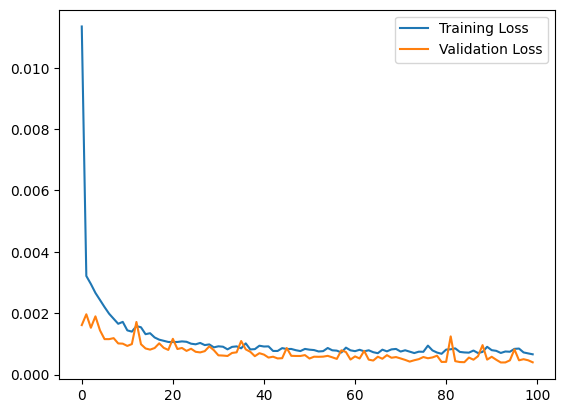

In [ ]:
import matplotlib.pyplot as plt
loss= history.history['loss']
val_loss= history.history['val_loss']

plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(X_test)
# Dùng scaler đã fit trước đó để inverse transform
predictions_reshaped = np.zeros((predictions.shape[0], 5))
predictions_reshaped[:, 3] = predictions[:, 0].flatten()
predictions = scaler.inverse_transform(predictions_reshaped)[:, 3]  # Cột 3 là giá Close
predictions[:10]

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


19.902363345623012

In [ ]:
y_test_reshaped = np.zeros((y_test.shape[0], 5))  # Tạo mảng zeros (543, 27, 5)
y_test_reshaped[:, 3] = y_test[:]  # Đặt giá trị y_test vào cột "Close" (vị trí 3)

# Áp dụng inverse_transform
y_test_real = scaler.inverse_transform(y_test_reshaped)[:, 3]

In [ ]:
y_test_real[:10]

20.230000000000004

In [ ]:
for i,j in zip(predictions[:10], y_test_real[:10]):
  print(i,j)

19.902363345623012 20.230000000000004
19.938053538799284 20.06
12.764199277758598 12.19
8.711328823566436 8.77
8.864038139879703 8.8
11.192804511189461 11.65
19.91845998764038 19.63
13.628624357581138 13.46
15.332574243545531 15.07
16.26676591873169 16.44
